In [1]:
import pandas as pd
import numpy as np

In [2]:
data_path = "../data/raw/collider_synthetic_practice-performance/collider_synthetic_data.csv"

df = pd.read_csv(data_path)

df.head()

,practice,skill,selected,performance
0,11.2,52.6,0,62.8
1,5.8,63.5,0,63.9
2,13.0,27.9,0,53.9
3,13.8,45.7,0,65.4
4,2.2,62.4,0,57.0


In [3]:
# basic dataset checks
print("Shape:", df.shape)
print()
print(df.dtypes)
print()
print(df.isna().sum())

Shape: (10000, 4)

practice       float64
skill          float64
selected         int64
performance    float64
dtype: object

practice       0
skill          0
selected       0
performance    0
dtype: int64


In [4]:
# basic generated-data checks
print("Selected share:")
print(df["selected"].value_counts(normalize=True).round(3))

print("\nSummary:")
print(df[["practice", "skill", "performance"]].describe().round(2))

Selected share:
selected
0    0.75
1    0.25
Name: proportion, dtype: float64

Summary:
       practice     skill  performance
count  10000.00  10000.00     10000.00
mean       9.97     50.31        65.04
std        4.00     15.03         9.82
min        0.00      0.00        25.70
25%        7.30     40.10        58.40
50%        9.90     50.10        65.00
75%       12.60     60.40        71.60
max       25.00    100.00       100.40


In [5]:
# compare practice-skill correlation before and after selection
df_selected = df[df["selected"] == 1]

full_corr = df["practice"].corr(df["skill"])
selected_corr = df_selected["practice"].corr(df_selected["skill"])

print(f"Practice-skill correlation, full population: {full_corr:.3f}")
print(f"Practice-skill correlation, selected players: {selected_corr:.3f}")

Practice-skill correlation, full population: -0.012
Practice-skill correlation, selected players: -0.430


In [6]:
# naive practice-performance slopes with 95% confidence intervals
full_coef, full_cov = np.polyfit(
    df["practice"],
    df["performance"],
    1,
    cov=True
)

selected_coef, selected_cov = np.polyfit(
    df_selected["practice"],
    df_selected["performance"],
    1,
    cov=True
)

full_slope = full_coef[0]
selected_slope = selected_coef[0]

# standard errors of the slope estimates
full_se = np.sqrt(full_cov[0, 0])
selected_se = np.sqrt(selected_cov[0, 0])

# 95% confidence intervals
full_ci_lower = full_slope - 1.96 * full_se
full_ci_upper = full_slope + 1.96 * full_se

selected_ci_lower = selected_slope - 1.96 * selected_se
selected_ci_upper = selected_slope + 1.96 * selected_se

print(f"True practice effect: {1.5:.3f}")
print(f"Naive slope, full population: {full_slope:.3f}")
print(f"95% CI: [{full_ci_lower:.3f}, {full_ci_upper:.3f}]")

print(f"\nNaive slope, selected players: {selected_slope:.3f}")
print(f"95% CI: [{selected_ci_lower:.3f}, {selected_ci_upper:.3f}]")

True practice effect: 1.500
Naive slope, full population: 1.479
95% CI: [1.440, 1.517]

Naive slope, selected players: 0.834
95% CI: [0.754, 0.915]


In [12]:
# adjust for skill in the selected sample
x = np.column_stack([
    np.ones(len(df_selected)),
    df_selected["practice"],
    df_selected["skill"]
])

y = df_selected["performance"].to_numpy()

beta = np.linalg.lstsq(x, y, rcond=None)[0]

adjusted_practice_effect = beta[1]

# calculate 95% confidence interval
residuals = y - x @ beta

n = len(y)
p = x.shape[1]

residual_variance = np.sum(residuals**2) / (n - p)
cov_beta = residual_variance * np.linalg.inv(x.T @ x)

adjusted_se = np.sqrt(cov_beta[1, 1])

adjusted_ci_lower = adjusted_practice_effect - 1.96 * adjusted_se
adjusted_ci_upper = adjusted_practice_effect + 1.96 * adjusted_se

print(f"Adjusted practice effect: {adjusted_practice_effect:.3f}")
print(f"95% CI: [{adjusted_ci_lower:.3f}, {adjusted_ci_upper:.3f}]")

Adjusted practice effect: 1.498
95% CI: [1.432, 1.563]


In [13]:
# summarize main results
results = pd.DataFrame({
    "Method": [
        "Naive full population",
        "Naive selected sample",
        "Adjusted selected sample",
        "True causal effect"
    ],
    "Effect": [
        full_slope,
        selected_slope,
        adjusted_practice_effect,
        1.5
    ],
    "95% CI": [
        f"[{full_ci_lower:.3f}, {full_ci_upper:.3f}]",
        f"[{selected_ci_lower:.3f}, {selected_ci_upper:.3f}]",
        f"[{adjusted_ci_lower:.3f}, {adjusted_ci_upper:.3f}]",
        "—"
    ]
})

results["Effect"] = results["Effect"].round(3)

results

,Method,Effect,95% CI
0,Naive full population,1.479,"[1.440, 1.517]"
1,Naive selected sample,0.834,"[0.754, 0.915]"
2,Adjusted selected sample,1.498,"[1.432, 1.563]"
3,True causal effect,1.500,—


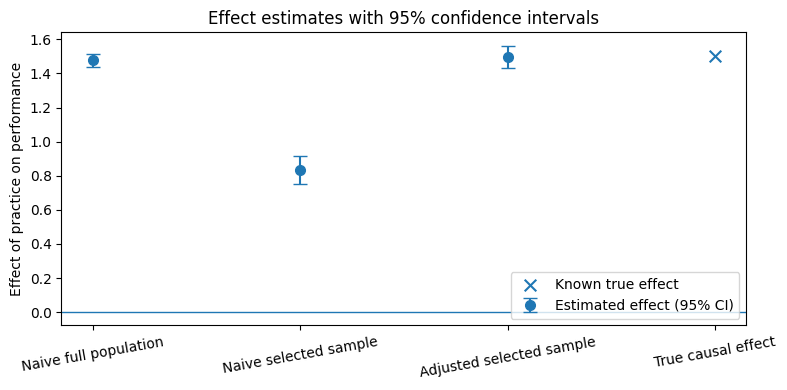

In [14]:
import matplotlib.pyplot as plt
import numpy as np

methods = [
    "Naive full population",
    "Naive selected sample",
    "Adjusted selected sample",
    "True causal effect"
]

effects = np.array([
    full_slope,
    selected_slope,
    adjusted_practice_effect,
    1.5
], dtype=float)

x = np.arange(len(methods))

plt.figure(figsize=(8, 4))

# 95% confidence intervals for the estimated effects
lower_errors = np.array([
    full_slope - full_ci_lower,
    selected_slope - selected_ci_lower,
    adjusted_practice_effect - adjusted_ci_lower
])

upper_errors = np.array([
    full_ci_upper - full_slope,
    selected_ci_upper - selected_slope,
    adjusted_ci_upper - adjusted_practice_effect
])

plt.errorbar(
    x[:3],
    effects[:3],
    yerr=[lower_errors, upper_errors],
    fmt="o",
    capsize=5,
    markersize=7,
    linestyle="none",
    label="Estimated effect (95% CI)"
)

# known true effect
plt.scatter(
    x[3],
    effects[3],
    marker="x",
    s=70,
    label="Known true effect"
)

plt.axhline(0, linewidth=1)
plt.xticks(x, methods, rotation=10)
plt.ylabel("Effect of practice on performance")
plt.title("Effect estimates with 95% confidence intervals")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

### Interpretation

In the full population, the naive relationship between practice and performance is close to the true causal effect of +1.5 performance points per additional hour of practice.

After restricting the analysis to tournament-qualified players, the naive estimate decreases substantially to approximately +0.83. This occurs because tournament qualification is a collider influenced by both practice and skill. Conditioning on qualification induces a negative association between practice and skill within the selected sample.

After additionally accounting for skill, the estimated practice effect increases to approximately +1.50, closely matching the known causal effect. The case therefore demonstrates how selection on a collider can introduce substantial bias into an otherwise valid associational relationship.

## Sensitivity Analysis: Strength of Selection

The main scenario restricts the analysis to the top 25% of players according to the qualification score. To assess how the strength of selection affects collider bias, the qualification threshold is varied while keeping the underlying data-generating process and true practice effect unchanged.

In [10]:
# regenerate the original population with full precision
rng = np.random.default_rng(42)
n = 10000

practice = np.clip(rng.normal(10, 4, n), 0, 25)
skill = np.clip(rng.normal(50, 15, n), 0, 100)

qualification_noise = rng.normal(0, 5, n)
qualification_score = (
    2.0 * practice
    + 0.5 * skill
    + qualification_noise
)

performance_noise = rng.normal(0, 5, n)
performance = (
    30
    + 1.5 * practice
    + 0.4 * skill
    + performance_noise
)

In [11]:
selection_scenarios = {
    "Weak selection": 0.50,
    "Original selection": 0.25,
    "Strong selection": 0.10
}

sensitivity_results = []

for name, selected_share in selection_scenarios.items():
    threshold = np.quantile(
        qualification_score,
        1 - selected_share
    )

    selected_mask = qualification_score >= threshold

    selected_practice = practice[selected_mask]
    selected_skill = skill[selected_mask]
    selected_performance = performance[selected_mask]

    corr = np.corrcoef(
        selected_practice,
        selected_skill
    )[0, 1]

    naive_effect = np.polyfit(
        selected_practice,
        selected_performance,
        1
    )[0]

    X = np.column_stack([
        np.ones(len(selected_practice)),
        selected_practice,
        selected_skill
    ])

    beta = np.linalg.lstsq(
        X,
        selected_performance,
        rcond=None
    )[0]

    adjusted_effect = beta[1]

    sensitivity_results.append({
        "Scenario": name,
        "Selected share": selected_share,
        "Practice-skill correlation": corr,
        "Naive effect": naive_effect,
        "Adjusted effect": adjusted_effect
    })

sensitivity_results = pd.DataFrame(sensitivity_results)

sensitivity_results[
    ["Practice-skill correlation", "Naive effect", "Adjusted effect"]
] = sensitivity_results[
    ["Practice-skill correlation", "Naive effect", "Adjusted effect"]
].round(3)

sensitivity_results

,Scenario,Selected share,Practice-skill correlation,Naive effect,Adjusted effect
0,Weak selection,0.50,-0.35,0.959,1.498
1,Original selection,0.25,-0.43,0.834,1.498
2,Strong selection,0.10,-0.50,0.740,1.531


### Sensitivity Analysis Interpretation

The sensitivity analysis shows that collider bias becomes stronger as tournament selection becomes more restrictive. When the top 50% of players are selected, the induced correlation between practice and skill is approximately -0.35 and the naive practice effect is estimated at 0.959. Under the original top-25% selection rule, the correlation decreases to approximately -0.43 and the naive estimate falls to 0.834. With only the top 10% selected, the correlation becomes approximately -0.50 and the naive estimate decreases further to 0.740.

In contrast, the adjusted estimates remain close to the known causal effect of 1.5 across all three scenarios. This indicates that the degree of disagreement between the selected-sample association and the causal effect increases as conditioning on the collider becomes more restrictive.